# Nivell 1

## Exercici 1
Importa com un DataFrame l'arxiu sprint10.xlsx. Assegura't que el fitxer s'importa correctament, amb els noms de columnes que li corresponen, sense manipular l'arxiu original.

Ordena el DataFrame pel país d'origen. En cas d'empat, ordena pel nom de la ciutat.

Mostra les primeres 10 files.

Addicionalment, fes un print on comprovi que el DNI només té valors únics.

In [1]:
import pandas as pd

# Header= None elimina el encabezado predeterminado
df = pd.read_excel(r"C:\Users\irene\Desktop\DataAnalytics\Bootcamp\Python\Sprint 10 nuevo\sprint10.xlsx", skiprows=3,index_col=0) 
df = df.sort_values(by=["País d'origen", 'Ciutat'])        # Ordeno por país
df.head(10)

,Nom,Cognoms,DNI,País d'origen,Ciutat,Dia de Naixement,Mes de Naixement,Any de Naixement,Gènere,Salari mensual,Fills,No Fills,Grup Professional
21,Mia,Schneider Fischer,28973553Z,Alemanya,Berlín,22,10,1976,A,951 €,NaN,1.0,Grup A
154,Laura,Schneider Fischer,37399141L,Alemanya,Berlín,2,2,1958,D,1.769 €,1.0,NaN,Grup B
224,Lea,Schneider Schneider,37368317L,Alemanya,Berlín,23,10,2005,D,2.013 €,NaN,1.0,Grup B
278,Mia,Fischer,21390098Z,Alemanya,Berlín,11,8,1950,D,1.557 €,1.0,NaN,Grup B
602,Jonas,Schneider,44060014R,Alemanya,Berlín,22,11,1985,H,2.754 €,1.0,NaN,Grup D
871,Lea,Fischer,14773153R,Alemanya,Berlín,9,9,1986,D,1.370 €,1.0,NaN,Grup A
281,Lea,Müller,23266650S,Alemanya,Hamburg,14,4,2003,D,1.314 €,NaN,1.0,Grup A
435,Anna,Müller,83274277X,Alemanya,Hamburg,1,1,1987,D,2.464 €,NaN,1.0,Grup C
444,Laura,Schmidt Müller,60161784X,Alemanya,Hamburg,15,6,1987,NC,2.035 €,1.0,NaN,Grup C
487,Lukas,Müller Fischer,60982309S,Alemanya,Hamburg,28,3,1971,H,2.042 €,NaN,1.0,Grup B


In [2]:
print(df['DNI'].nunique() == len(df))   # Imprime True si la cantidad de registros de DNI diferentes es = a la cant de registros del df

True


## Exercici 2
- Crea una columna que sigui el nom complet
- Crea una columna si la persona és nascuda a Espanya o no
- Posa el DNI com a índex del DataFrame (noms de files)
- Substitueix el nom de les columnes Dia de Naixement, Mes de Naixement i Any de Naixement per Dia, Mes i Any
- Substitueix H per Home, D per Dona, A per Altres i NC per una dada faltant (nan/null/na)
- Mostra tots els canvis que has realitzat en una sola taula.

In [3]:
df['Nombre Completo'] = df.apply( lambda row: f'{row['Nom']} {row['Cognoms']}' , axis= 1 )
df['Español'] = df ['País d\'origen'].apply(lambda x:True if x == 'Espanya'  else False)
df.set_index('DNI', inplace=True)
df.rename(columns={'Dia de Naixement': 'Dia', 'Mes de Naixement' : 'Mes',  'Any de Naixement': 'Any'}, inplace=True)
diccionario_genero = {'H':'Home','D':'Dona', 'A':'Altres',}
df [ 'Gènere' ] = df [ 'Gènere' ].map(diccionario_genero).fillna( 'NC' ) 

In [4]:
df

,Nom,Cognoms,País d'origen,Ciutat,Dia,Mes,Any,Gènere,Salari mensual,Fills,No Fills,Grup Professional,Nombre Completo,Español
DNI,,,,,,,,,,,,,,
28973553Z,Mia,Schneider Fischer,Alemanya,Berlín,22,10,1976,Altres,951 €,NaN,1.0,Grup A,Mia Schneider Fischer,False
37399141L,Laura,Schneider Fischer,Alemanya,Berlín,2,2,1958,Dona,1.769 €,1.0,NaN,Grup B,Laura Schneider Fischer,False
37368317L,Lea,Schneider Schneider,Alemanya,Berlín,23,10,2005,Dona,2.013 €,NaN,1.0,Grup B,Lea Schneider Schneider,False
21390098Z,Mia,Fischer,Alemanya,Berlín,11,8,1950,Dona,1.557 €,1.0,NaN,Grup B,Mia Fischer,False
44060014R,Jonas,Schneider,Alemanya,Berlín,22,11,1985,Home,2.754 €,1.0,NaN,Grup D,Jonas Schneider,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
89577876S,Emily,Taylor Jones,Regne Unit,Manchester,28,3,1958,Dona,2.033 €,NaN,1.0,Grup B,Emily Taylor Jones,False
57441590Y,George,Brown Jones,Regne Unit,Manchester,27,12,1979,Home,1.130 €,1.0,NaN,Grup A,George Brown Jones,False
58204038A,Olivia,Brown Brown,Regne Unit,Manchester,28,8,1952,Altres,1.023 €,NaN,1.0,Grup A,Olivia Brown Brown,False


## Exercici 3:
Junta les columnes Fills i No Fills en una sola columna, utilitzant el mètode .apply() i definint una funció que resolgui el problema. La columna nova ha de dir-se "Fills" i prendre els valors "Sí" o "No".

In [5]:
df [ 'Fills' ] = df [ 'Fills' ].apply(lambda x:'Si' if x == True else 'No') 
df = df.drop('No Fills', axis=1)
df

,Nom,Cognoms,País d'origen,Ciutat,Dia,Mes,Any,Gènere,Salari mensual,Fills,Grup Professional,Nombre Completo,Español
DNI,,,,,,,,,,,,,
28973553Z,Mia,Schneider Fischer,Alemanya,Berlín,22,10,1976,Altres,951 €,No,Grup A,Mia Schneider Fischer,False
37399141L,Laura,Schneider Fischer,Alemanya,Berlín,2,2,1958,Dona,1.769 €,Si,Grup B,Laura Schneider Fischer,False
37368317L,Lea,Schneider Schneider,Alemanya,Berlín,23,10,2005,Dona,2.013 €,No,Grup B,Lea Schneider Schneider,False
21390098Z,Mia,Fischer,Alemanya,Berlín,11,8,1950,Dona,1.557 €,Si,Grup B,Mia Fischer,False
44060014R,Jonas,Schneider,Alemanya,Berlín,22,11,1985,Home,2.754 €,Si,Grup D,Jonas Schneider,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...
89577876S,Emily,Taylor Jones,Regne Unit,Manchester,28,3,1958,Dona,2.033 €,No,Grup B,Emily Taylor Jones,False
57441590Y,George,Brown Jones,Regne Unit,Manchester,27,12,1979,Home,1.130 €,Si,Grup A,George Brown Jones,False
58204038A,Olivia,Brown Brown,Regne Unit,Manchester,28,8,1952,Altres,1.023 €,No,Grup A,Olivia Brown Brown,False


## Exercici 4:
Crea una taula resum que permeti veure el sou mig, medià, mínim i màxim per Gènere.
Ordena la taula en funció del sou mig.

In [6]:
df['Salari mensual'] = (
    df['Salari mensual']
    .astype(str)
    .str.replace('.', '', regex=False)  # borra puntos de miles
    .str.replace('€', '', regex=False)  # borra €
    .str.replace(',', '.', regex=False)  # cambia coma por punto decimal
    .astype(float)
)

In [7]:
resumen = df.groupby('Gènere')['Salari mensual'].agg(['mean', 'median', 'min', 'max']).sort_values(by='mean', ascending=False)
resumen.columns = ['Mitjana', 'Medià', 'Mínim', 'Màxim']
resumen

,Mitjana,Medià,Mínim,Màxim
Gènere,,,,
Home,1643.249443,1531.0,737.0,3356.0
Altres,1626.588235,1545.0,703.0,3175.0
NC,1568.866667,1443.0,758.0,2969.0
Dona,1469.443182,1361.5,665.0,3021.0


## Exercici 5
Crea una taula resum amb el salari mig per gènere (files) i país d'origen (columnes).
Afegeix-hi les mitjanes als marges de la taula.
(EXTRA):  

In [8]:
salario_genero_pais = pd.crosstab(df['Gènere'],df['País d\'origen'], df['Salari mensual'], aggfunc='mean', margins=True)
salario_genero_pais.style.background_gradient('coolwarm')

País d'origen,Alemanya,Argentina,Colòmbia,Espanya,França,Itàlia,Marroc,Mèxic,Portugal,Regne Unit,All
Gènere,,,,,,,,,,,
Altres,951.000000,1141.000000,1030.000000,1706.176471,nan,1423.000000,1365.000000,1372.000000,1765.000000,1921.000000,1626.588235
Dona,1804.307692,1291.800000,1497.750000,1460.163987,1566.470588,1247.181818,1405.214286,1517.800000,1488.545455,1489.461538,1469.443182
Home,2067.428571,1583.294118,1554.666667,1682.105740,1389.250000,1672.875000,1531.000000,1625.000000,1497.000000,1162.555556,1643.249443
NC,1931.500000,1135.666667,1252.000000,1597.139535,1573.000000,1316.000000,1365.500000,1583.000000,1553.500000,1758.000000,1568.866667
All,1858.347826,1431.677419,1489.131579,1582.162726,1465.357143,1421.173913,1441.689655,1559.081081,1527.225806,1448.333333,1561.462000


## Exercici 6
Crea una columna nova que sigui la data de naixament en format Datetime a partir de les columnes dia, mes i any. Utilitzant aquesta columna crea una funció que donada una data, et calculi l'edat actual a dia d'avui.
Utilitza la funció que acabes de crear per generar una columna nova al DataFrame amb l'edat actual.

In [9]:
df[ 'Fecha Nacimiento' ] = df.apply( lambda row: f" {row[ 'Dia' ]}/{row[ 'Mes' ]}/{row[ 'Any' ]}" , axis= 1 ) 
df['Fecha Nacimiento'] = pd.to_datetime(df['Fecha Nacimiento'])

def calcular_edad(row):
    hoy = pd.to_datetime('today')
    fecha_nacimiento = row['Fecha Nacimiento'] 
    edad = hoy.year - fecha_nacimiento.year
    return edad 

df [ 'Edad' ] = df.apply(calcular_edad,axis=1) 

df = df.drop(columns=['Dia', 'Mes', 'Any'])

C:\Users\irene\AppData\Local\Temp\ipykernel_78364\2832603463.py:2: UserWarning: Parsing dates in  %d/%m/%Y format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  df['Fecha Nacimiento'] = pd.to_datetime(df['Fecha Nacimiento'])


In [10]:
df.head()

,Nom,Cognoms,País d'origen,Ciutat,Gènere,Salari mensual,Fills,Grup Professional,Nombre Completo,Español,Fecha Nacimiento,Edad
DNI,,,,,,,,,,,,
28973553Z,Mia,Schneider Fischer,Alemanya,Berlín,Altres,951.0,No,Grup A,Mia Schneider Fischer,False,1976-10-22,49
37399141L,Laura,Schneider Fischer,Alemanya,Berlín,Dona,1769.0,Si,Grup B,Laura Schneider Fischer,False,1958-02-02,67
37368317L,Lea,Schneider Schneider,Alemanya,Berlín,Dona,2013.0,No,Grup B,Lea Schneider Schneider,False,2005-10-23,20
21390098Z,Mia,Fischer,Alemanya,Berlín,Dona,1557.0,Si,Grup B,Mia Fischer,False,1950-08-11,75
44060014R,Jonas,Schneider,Alemanya,Berlín,Home,2754.0,Si,Grup D,Jonas Schneider,False,1985-11-22,40


# NIVEL 2

## Exercici 1: 

Utilitzant el següent DataFrame, adjunta la columna "Increment" al dataframe del nivell anterior.
Actualitza la columna salari en funció dels percentatges que s'adjunten. No modifiquis manualment els increments, escriu codi Python per fer les conversions necessàries.

In [11]:
import pandas as pd
df_increment = pd.DataFrame({"Grup":["Grup A","Grup B","Grup C", "Grup D" ] ,  "Increment": ["5%","3,5%","2%","8%"]})
df_increment

,Grup,Increment
0,Grup A,5%
1,Grup B,"3,5%"
2,Grup C,2%
3,Grup D,8%


In [ ]:
df = pd.merge(df.reset_index(), df_increment, left_on='Grup Professional', right_on= 'Grup', how= 'outer').set_index('DNI')
df = df.drop(columns='Grup')

df['Increment'] = df['Increment'].str.replace('%', '', regex=False).str.replace(',', '.').astype(float)

df['Salari mensual'] = df.apply(
    lambda row: row['Salari mensual'] * (1 + row['Increment'] / 100),
    axis=1)
df.rename(columns={'Salari mensual': 'Salari mensual (€)'}, inplace =True)
df.rename(columns={'Increment': 'Increment_%'}, inplace=True)
df.head()

,Nom,Cognoms,País d'origen,Ciutat,Gènere,Salari mensual (€),Fills,Grup Professional,Nombre Completo,Español,Fecha Nacimiento,Edad,Increment_%
DNI,,,,,,,,,,,,,
28973553Z,Mia,Schneider Fischer,Alemanya,Berlín,Altres,998.55,No,Grup A,Mia Schneider Fischer,False,1976-10-22,49,5.0
14773153R,Lea,Fischer,Alemanya,Berlín,Dona,1438.50,Si,Grup A,Lea Fischer,False,1986-09-09,39,5.0
23266650S,Lea,Müller,Alemanya,Hamburg,Dona,1379.70,No,Grup A,Lea Müller,False,2003-04-14,22,5.0
74158500N,Laura,Schneider,Alemanya,Hamburg,Dona,1436.40,No,Grup A,Laura Schneider,False,1957-01-25,68,5.0
23128433S,Anna,Müller,Alemanya,Munic,Dona,1344.00,No,Grup A,Anna Müller,False,1956-03-18,69,5.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
28237150F,Giovanni,Rossi Russo,Itàlia,Torí,Home,3093.12,Si,Grup D,Giovanni Rossi Russo,False,2000-12-10,25,8.0
99258742G,Amina,Bennani,Marroc,Casablanca,Dona,3183.84,Si,Grup D,Amina Bennani,False,2004-10-22,21,8.0
81992107P,María,Cruz,Mèxic,Ciutat de Mèxic,Dona,2865.24,Si,Grup D,María Cruz,False,1958-03-14,67,8.0


## Exercici 2:

Utilitzant un bucle, exporta en 4 fitxers (format .xlsx o .csv) les dades de cada Grup Professional.
Per exemple: "dades_GrupA.xlsx" , "dades_GrupB.xlsx" ...

Exporta un 5è DataFrame en format .xlsx o .csv que contingui quants treballadors hi ha per cada Grup Professional, quin és el seu sou mig i quina és la seva edat mediana.

In [13]:
grupos = df['Grup Professional'].unique()

for grupo in grupos:
    df_grupo = df[df['Grup Professional'] == grupo]
    nombre_archivo = f"{grupo.replace(' ', '_')}.csv"
    df_grupo.to_csv(nombre_archivo, index=True)

(Extra: Explora com fer-ho tot en un sol excel, on hi hagi una pestanya per cada dataframe)

In [16]:
df_reset = df.reset_index()                             # DNI vuelve a ser columna
df5 = df_reset.groupby('Grup Professional').aggregate({
    'DNI': 'count',
    'Salari mensual (€)': 'mean',
    'Edad': 'median'
})

df5 = df5.rename(columns={
    'DNI': 'Trabajadores',
    'Salari mensual (€)': 'Media_salario/mes(€)',
    'Edad': 'Edad_mediana'
})

df5['Media_salario/mes(€)'] = df5['Media_salario/mes(€)'].round(2)

df = df_reset.set_index('DNI')                      # DNI vuelve a ser índice

df5

,Trabajadores,Media_salario/mes(€),Edad_mediana
Grup Professional,,,
Grup A,490,1213.32,50.0
Grup B,318,1724.55,47.0
Grup C,137,2289.19,51.0
Grup D,55,3100.82,43.0


In [17]:
with pd.ExcelWriter("treballadors_per_grup.xlsx") as writer:
    for grupo in grupos:
        df_grupo = df[df['Grup Professional'] == grupo]
        nombre_hoja = grupo.replace(" ", "_")
        df_grupo.to_excel(writer, sheet_name=nombre_hoja, index=True)


# Nivell 3

El nivell 3 d’aquest sprint és totalment diferent a d’altres sprints que has fet fins ara, ja que són exercicis més abstractes que requereixen barallar-s’hi bastant. No continuen amb el mateix dataset dels nivells anteriors, sinó que et plantegen dues situacions noves totalment diferents entre elles.

## Exercici 1:

Crea una funció que prengui un dataframe com a paràmetre d'entrada.
La funció ha de crear (i exportar) un gràfic automàticament per a cada columna del dataframe. Per exemple:
- un histograma/boxplot si la variable és numèrica
- unes barres dels valors més freqüents si és categòrica 
- unes barres dels anys més freqüents si la dada està en format data.

La idea és crear una funció que funcioni per qualsevol dataframe, no només amb el que hem treballat fins ara. 
Mostra el resultat de la funció en algun dels datasets d’exemple que conté el paquet seaborn. Per exemple, iris, penguins o titanic.


In [18]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from pandas.api import types
import numpy as np 

In [19]:
def leer_archivo(ruta_archivo, formato='auto'):
    """
    Lee un archivo de diferentes formatos (CSV, Excel) y devuelve un DataFrame de Pandas.

    Args:
        ruta_archivo (str): Ruta al archivo a leer.
        formato (str, optional): Formato del archivo. Por defecto, 'auto' intenta
                                 detectar el formato. Otros valores: 'csv', 'excel'.

    Returns:
        pandas.DataFrame: DataFrame con los datos del archivo.
    """
    try:
        
        if formato == 'csv' or (formato == 'auto' and ruta_archivo.lower().endswith('.csv')):
            df = pd.read_csv(ruta_archivo)
        elif formato == 'excel' or (formato == 'auto' and (ruta_archivo.lower().endswith('.xlsx') or ruta_archivo.lower().endswith('.xls'))):
            df = pd.read_excel(ruta_archivo)
        else:
            raise ValueError(f"Formato de archivo no soportado o no detectado: {formato}. Asegúrate de que la ruta termina en .csv, .xlsx o .xls, o especifica 'csv' o 'excel'.")
        
        return df
    except FileNotFoundError:
        raise FileNotFoundError(f"Error: El archivo no se encontró en la ruta especificada: {ruta_archivo}")
    except pd.errors.EmptyDataError:
        raise ValueError(f"Error: El archivo '{ruta_archivo}' está vacío o no contiene datos.")
    except pd.errors.ParserError as e:
        raise ValueError(f"Error al parsear el archivo '{ruta_archivo}'. Verifica el formato y el contenido: {e}")
    except Exception as e:
        raise Exception(f"Ocurrió un error inesperado al leer el archivo '{ruta_archivo}': {e}")

In [20]:
def _crear_histograma(df, columna):
	"""Genera un histograma para una columna numérica."""
	print(f"  -> Generando histograma para '{columna}'.")
	
	plt.figure(figsize=(8, 5))
	sns.histplot(data=df, x=columna, kde=True)
	plt.title(f'Distribución de {columna}')
	plt.xlabel(columna) 
	plt.ylabel('Frecuencia / Densidad') 
	plt.grid(axis='y', linestyle='--', alpha=0.7) 	# Cuadrícula general
	plt.tight_layout() 								# Ajuste de diseño para que no se solapen
	plt.show()

In [21]:
def _crear_graf_barras(df, columna):
	"""Genera un gráfico de barras para una columna categórica/booleana."""
	print(f"  -> Generando gráfico de barras para '{columna}'.")

	plt.figure(figsize=(7, 5))
	top_n = 20 									# Limitamos a 20 el número de categorías
	value_counts = df[columna].value_counts()

	if len(value_counts) > top_n:
		print(f"    (Más de {top_n} categorías. Mostrando solo las {top_n} más frecuentes.)")
		order = value_counts.head(top_n).index
	else:
		order = value_counts.index
	
	sns.countplot(data=df, x= columna, order=order)
	plt.title(f'Conteo de {columna}')
	plt.xlabel(columna)
	plt.ylabel('Conteo')
	plt.xticks(rotation=45, ha='right') 
	plt.grid(axis='y', linestyle='--', alpha=0.7)
	plt.tight_layout() 
	plt.show()

In [ ]:
def _crear_barras_fechas(df, columna):
    """Genera un gráfico de barras de frecuencia de años para una columna de fecha."""
    print(f"  -> Generando gráfico de barras por año para '{columna}'.")
    
    plt.figure(figsize=(7, 5))
    df_temporal = df.copy()     # Trabajo con una copia porque voy a hacer modificaciones en el df, creando una columna temporal de año
    
    df_temporal[columna] = pd.to_datetime(df_temporal[columna], errors='coerce')        # Convierte la columna a tipo datetime antes de intentar extraer el año
                                                                                        # El error='coerce': por si encuentra una fecha que no puede entender,
                                                                                        # la convierte a NaT (Not a Time), en lugar de generar un error.
    df_temporal.dropna(subset=[columna], inplace=True)                                  # Si hay valores NaT los quitamos para que no afecten el conteo de años.
    
    temp_year_col = f'{columna}_Año'                                                    # Le cmabiamos el nombre
    df_temporal[temp_year_col] = df_temporal[columna].dt.year                           # Le extraemos el año solamente

    df_temporal[temp_year_col] = df_temporal[temp_year_col].astype('Int64')             # Aseguramos que la columna de años es de un tipo que countplot pueda manejar bien
	
    sns.countplot(data=df_temporal, x=temp_year_col, 
                  order=df_temporal[temp_year_col].value_counts().sort_index().index)
    plt.title(f'Conteo de Registros por Año en {columna}')
    plt.xlabel('Año')
    plt.ylabel('Conteo')
    plt.xticks(rotation=45, ha='right')	
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.tight_layout()
    del df_temporal[temp_year_col]                      # Limpiar la columna temporal
    plt.show()

In [ ]:
def generador_graficos(ruta_archivo, formato='auto'):
	"""
    Genera automáticamente gráficos exploratorios para las columnas de un DataFrame.

    Esta función lee un archivo, y para cada columna, intenta generar un gráfico
    adecuado según su tipo de dato.

    IMPORTANTE: Asegúrate de que las columnas de fecha (ej. 'YYYY-MM-DD') estén
    correctamente tipadas como 'datetime64[ns]' en tu DataFrame original,
    o conviértelas ANTES de llamar a esta función.
    Por ejemplo: df['mi_columna_fecha'] = pd.to_datetime(df['mi_columna_fecha'], errors='coerce')

    Args:
        ruta_archivo (str): Ruta al archivo a leer.
        formato (str, optional): Formato del archivo. Por defecto, 'auto' intenta 
                                 detectar el formato. Otros valores: 'csv', 'excel'.
    """
	print(f"Iniciando cración de gráficas.")

	df_trabajo = leer_archivo(ruta_archivo, formato)
	print(f"DataFrame cargado con {len(df_trabajo.columns)} columnas y {len(df_trabajo)} filas.")
    
	tipos_columnas = df_trabajo.dtypes		# Esto es una serie
	
	for columna in df_trabajo.columns:		# Recorro una serie
		tipo_actual = tipos_columnas[columna]
		if pd.api.types.is_numeric_dtype(tipo_actual):
			_crear_histograma(df_trabajo, columna)
					
		elif pd.api.types.is_object_dtype(tipo_actual) or pd.api.types.is_categorical_dtype() or pd.api.types.is_bool_dtype(tipo_actual):
			_crear_graf_barras(df_trabajo, columna)

		elif pd.api.types.is_datetime64_any_dtype(tipo_actual):
			_crear_barras_fechas(df_trabajo, columna)

		else:
			print(f"  -> {columna} es de otro tipo ({tipo_actual}). No se generará gráfico por ahora.")
			continue

		print("-" * 50)

	print("\nCreación de gráficas completada.")


--- Generando gráficos para el dataset Iris (desde iris_temp.csv) ---
Iniciando cración de gráficas.
DataFrame cargado con 5 columnas y 150 filas.
  -> Generando histograma para 'sepal_length'.


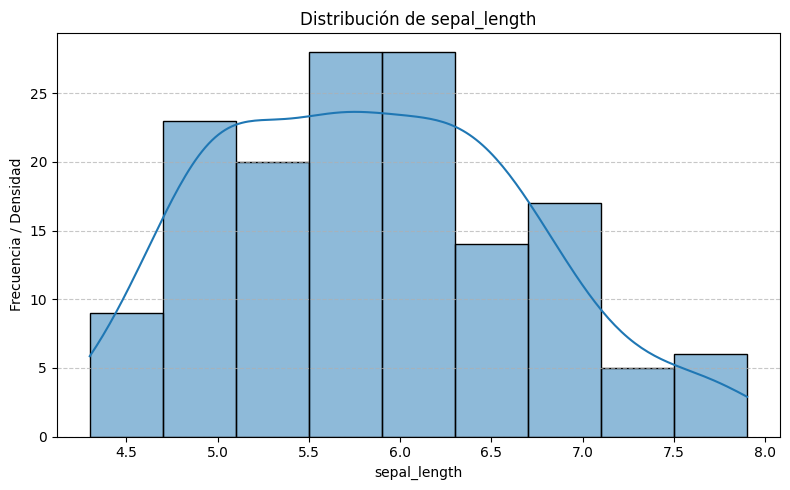

--------------------------------------------------
  -> Generando histograma para 'sepal_width'.


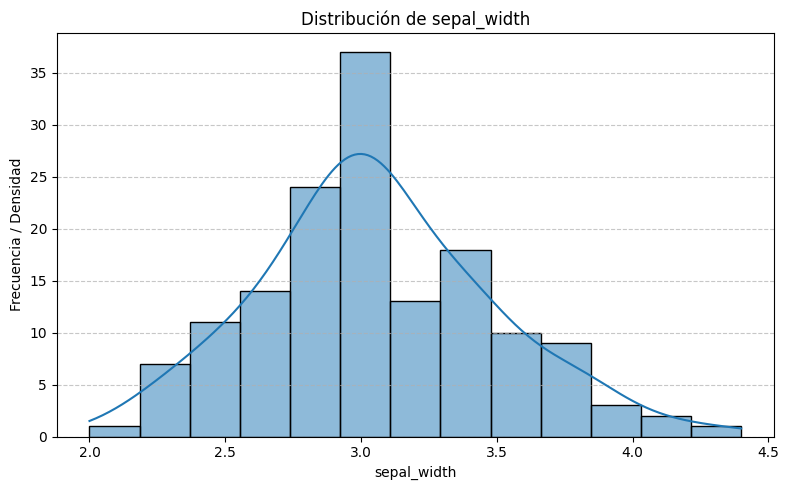

--------------------------------------------------
  -> Generando histograma para 'petal_length'.


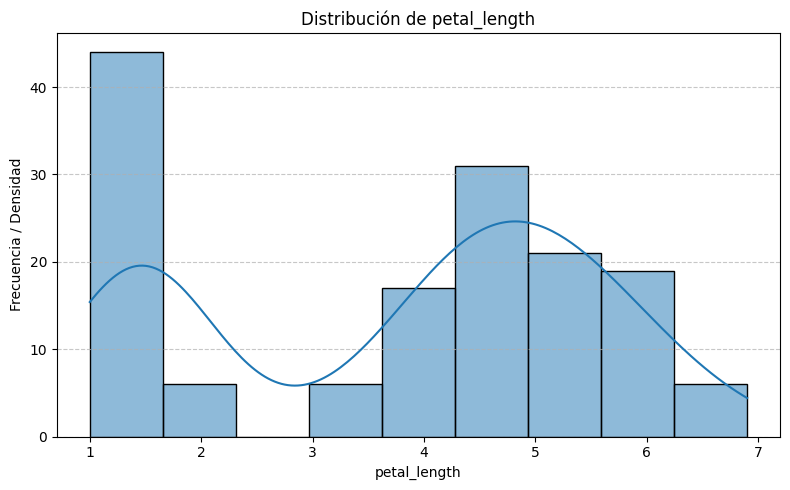

--------------------------------------------------
  -> Generando histograma para 'petal_width'.


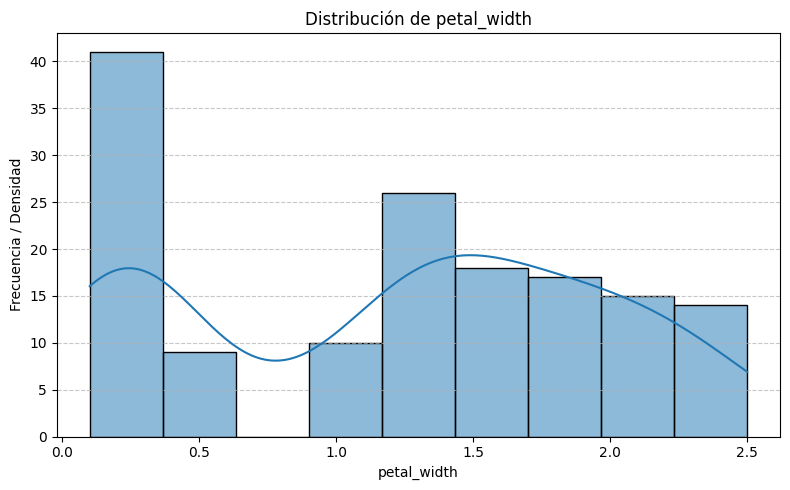

--------------------------------------------------
  -> Generando gráfico de barras para 'species'.


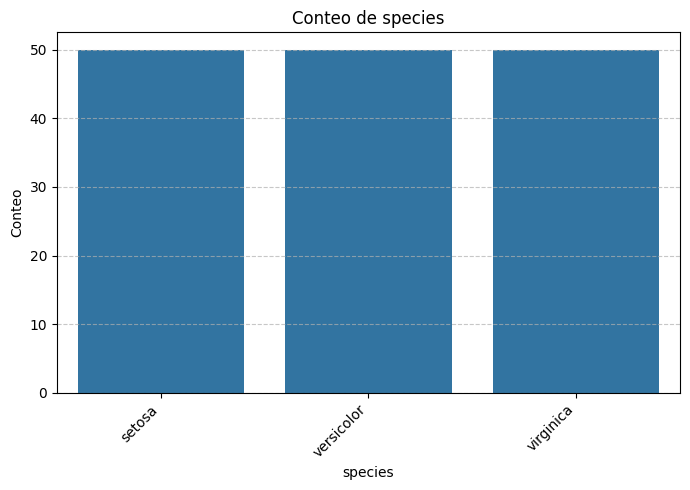

--------------------------------------------------

Creación de gráficas completa.


In [24]:
import os                               # Útil para manejar rutas y eliminar archivos temporales

# 1. Carga el dataset de Seaborn
df_iris = sns.load_dataset('iris')

# 2. Define una ruta para el archivo temporal
ruta_iris_temp = 'iris_temp.csv'

# Guarda los DataFrames de Seaborn en archivos CSV temporales
df_iris.to_csv(ruta_iris_temp, index=False) # index=False para no guardar el índice de Pandas como columna


print(f"\n--- Generando gráficos para el dataset Iris (desde {ruta_iris_temp}) ---")
try:
    generador_graficos(ruta_iris_temp, formato='csv')
except Exception as e:
    print(f"¡Oops! Ocurrió un error al procesar {ruta_iris_temp}: {e}")

# # 3. (Opcional) Elimina los archivos temporales si ya no los necesitas
# try:
#     os.remove(ruta_iris_temp)
#     os.remove(ruta_titanic_temp)
#     print("\nArchivos temporales eliminados correctamente.")
# except OSError as e:
#     print(f"Error al eliminar archivos temporales: {e}")

## Exercici 2:
Carrega l'arxiu distancies.csv a pandas, de manera que els noms de files i els noms de columnes siguin els de les ciutats. Borra "Las Palmas de Gran Canaria" i "Palma" perquè poguem fer el trajecte en cotxe.

Font: https://espana.mejoresrutas.com/tabla-de-distancias/es/

Ens interessa visitar totes les ciutats principals d'Espanya recorrent la mínima distància possible.

No cal que ho facis de forma òptima, ens interessa que desenvolupis una solució raonable utilitzant les eines que tens actualment.

Per exemple, una aproximació senzilla (que no òptima) seria anant sempre a la ciutat més propera que no haguem visitat encara.

Fes una funció que donada la matriu de distàncies i la ciutat d'origen, faci una proposta de ruta que sigui el més curta possible que puguis, retornant una llista amb l'ordre de visita. Dóna també la distància total recorreguda.

(EXTRA) Des de quina ciutat la ruta seria més curta amb l'algoritme plantejat??

In [26]:
import pandas as pd
distancias = pd.read_csv(r"C:\Users\irene\Desktop\DataAnalytics\Bootcamp\Python\Sprint 10 nuevo\es.csv")
distancias.drop(columns=['Palma','Las Palmas de Gran Canaria'], inplace=True)
distancias.drop(index=[6, 7, 15, 16, 17], inplace=True)
distancias.fillna(0, inplace=True)
distancias.rename(columns={'Distancia (kilómetros)': 'Ciudad'}, inplace=True)
distancias.set_index('Ciudad', inplace=True)
distancias

,Barcelona,Valencia,Sevilla,Zaragoza,Málaga,Murcia,Bilbao,Alicante,Córdoba,Valladolid,Vigo,Gijón,Hospitalet de Llobregat
Ciudad,,,,,,,,,,,,,
Barcelona,0.0,350.0,999.0,310.0,953.0,567.0,609.0,516.0,863.0,727.0,1142.0,874.0,13.0
Valencia,350.0,0.0,658.0,310.0,604.0,218.0,612.0,166.0,523.0,566.0,946.0,822.0,342.0
Sevilla,998.0,659.0,0.0,841.0,210.0,528.0,859.0,601.0,143.0,581.0,773.0,796.0,990.0
Zaragoza,309.0,310.0,842.0,0.0,834.0,526.0,303.0,475.0,701.0,421.0,836.0,568.0,301.0
Málaga,953.0,607.0,210.0,834.0,0.0,400.0,923.0,473.0,159.0,739.0,979.0,1002.0,946.0
Murcia,566.0,220.0,527.0,526.0,400.0,0.0,781.0,82.0,434.0,607.0,986.0,863.0,559.0
Bilbao,609.0,611.0,859.0,303.0,922.0,782.0,0.0,776.0,789.0,279.0,666.0,265.0,601.0
Alicante,514.0,168.0,600.0,474.0,473.0,82.0,776.0,0.0,507.0,631.0,1011.0,887.0,506.0
Córdoba,860.0,521.0,143.0,698.0,157.0,433.0,787.0,506.0,0.0,604.0,830.0,860.0,853.0


In [29]:
distancias
def generar_ruta(distancias: pd.DataFrame, origen: str):
    total_kms = 0

    if origen not in distancias.index:
            print(f"Error: La ciudad de origen '{origen}' no se encuentra en el listado de ciudades.")
            return [], 0 # Retorna una ruta vacía y 0 kms en caso de error

    ciudades_visitadas = []
    ciudades_visitadas.append(origen)
    ciudad_actual= origen
    total_ciudades = len(distancias.index)

    while len(ciudades_visitadas) < total_ciudades:

        distancias_desde_actual = distancias.loc[ciudad_actual]                         # Saco listado de km a ciudades a las que se puede ir desde mi c.actual
        ciudades_no_visitadas = ~distancias_desde_actual.index.isin(ciudades_visitadas) # Selecciono de los km de las ciudades ciudades disponibles, su indice (el decir, el nombre de la ciudad) q no estan en la lista de las c_visitadas. obtengo los indices, es decir, la lista de ciudades
        distancias_filtradas_para_seleccion = distancias_desde_actual[ciudades_no_visitadas] # Aqui filtro por c. no visitadas, y obtengo los km de distancia hacia cada una de esas ciudades. obtengo los datos de km
        kms = distancias_filtradas_para_seleccion.min()                     # Aqui voy al dato de la celda
        ciudad_destino = distancias_filtradas_para_seleccion.idxmin()       # Aqui voy a su indice, es decir el nombre de la ciudad    
        ciudades_visitadas.append(ciudad_destino)
        ciudad_actual=ciudad_destino
        total_kms += kms
    return ciudades_visitadas, total_kms

In [31]:
# Pide la ciudad de origen al usuario UNA VEZ (antes de llamar a la función)
ciudad_elegida_por_usuario = input('Introduce la ciudad de origen: ')

# Llamar a la función, pasándole el DataFrame 'distancias' y la ciudad obtenida del usuario
ruta_propuesta, total_kms = generar_ruta(distancias=distancias, origen=ciudad_elegida_por_usuario)

# --- Formatear la ruta para la salida ---
ruta_formateada_para_mostrar = []
for i, ciudad in enumerate(ruta_propuesta):
    ruta_formateada_para_mostrar.append(f"{i+1}: {ciudad}")
ruta_final_string = "\n".join(ruta_formateada_para_mostrar)

# Muestra los resultados formateados
print(f"\nLa ruta propuesta es: \n\n{ruta_final_string}")
print('\n')
print(f"La distancia total recorrida es: {total_kms} km")



La ruta propuesta es: 

1: Málaga
2: Córdoba
3: Sevilla
4: Murcia
5: Alicante
6: Valencia
7: Zaragoza
8: Hospitalet de Llobregat
9: Barcelona
10: Bilbao
11: Gijón
12: Valladolid
13: Vigo


La distancia total recorrida es: 3328.0 km


### Extra: 
Des de quina ciutat la ruta seria més curta amb l'algoritme plantejat??


In [41]:
def buscar_ruta_mas_corta():
    ciudades = distancias.index
    lista_pares= []

    for ciudad in ciudades:
        resultado_ruta, resultado_km = generar_ruta(distancias= distancias, origen= ciudad)
        lista_pares.append((resultado_km, resultado_ruta))
    tupla_ruta_mas_corta = min(lista_pares)
    km_ruta_mas_corta, ruta_mas_corta = tupla_ruta_mas_corta
    ciudad_origen_mas_corta = ruta_mas_corta[0]

    return km_ruta_mas_corta, ruta_mas_corta, ciudad_origen_mas_corta 

In [44]:
km_ruta_mas_corta, ruta_mas_corta, ciudad_origen_mas_corta = buscar_ruta_mas_corta()
ruta_corta_mostrar = "\n".join(ruta_mas_corta)

print(f"La ruta más corta es de: {km_ruta_mas_corta} km, saliendo desde {ciudad_origen_mas_corta}.")
print(f"\nLas ciudades a recorrer son: \n\n{ruta_corta_mostrar}")

La ruta más corta es de: 2980.0 km, saliendo desde Vigo.

Las ciudades a recorrer son: 

Vigo
Gijón
Bilbao
Valladolid
Zaragoza
Hospitalet de Llobregat
Barcelona
Valencia
Alicante
Murcia
Málaga
Córdoba
Sevilla
